# Model Penilaian Kredit Nasabah (Credit Score Classification)

**Studi Kasus:** Sebuah institusi keuangan membutuhkan cara yang sistematis dan berbasis data untuk menilai performa kredit setiap nasabah. Setiap nasabah perlu dikelompokkan ke dalam salah satu dari tiga kategori risiko kredit, yaitu **Poor**, **Standard**, atau **Good**. Notebook ini berisi proses eksplorasi data, pembersihan data, pra-pemrosesan, eksperimen pemodelan, evaluasi, dan penyimpanan model akhir yang akan digunakan pada tahap deployment.

Notebook ini disusun mengikuti alur kerja standar seorang data scientist, yaitu:

1. Pemahaman dan eksplorasi data (EDA)
2. Pembersihan data dan pra-pemrosesan
3. Pembagian data latih dan data uji
4. Eksperimen beberapa algoritma machine learning
5. Pemilihan dan penyetelan model terbaik
6. Evaluasi model pada data uji
7. Penyimpanan model untuk kebutuhan deployment
8. Ringkasan penjelasan teknis (fitur, pra-pemrosesan, model, metrik evaluasi, dan eksperimen)

**Catatan revisi:** Versi ini memperbaiki dua celah arsitektural pada versi sebelumnya: (1) logika pembersihan data kini dibungkus sebagai *custom transformer* scikit-learn di dalam `Pipeline`, bukan dijalankan manual di luar pipeline, sehingga skrip inferencing saat deployment tidak perlu menduplikasi logika pembersihan; dan (2) validasi silang pada tahap eksperimen kini menggunakan `StratifiedGroupKFold` berbasis `Customer_ID`, agar baris dari nasabah yang sama tidak terpisah ke fold latih dan fold validasi yang berbeda di dalam data latih.


In [1]:
# 1. Import Library
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import pickle

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Memuat Data

Dataset berisi data bulanan setiap nasabah, mencakup informasi demografis, riwayat pinjaman, perilaku pembayaran, dan kondisi keuangan. Kolom target yang akan diprediksi adalah `Credit_Score`.

In [2]:
df_raw = pd.read_csv("data_D.csv", index_col=0)
print("Ukuran data:", df_raw.shape)
df_raw.head()

Ukuran data: (25000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,8,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,9,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,7,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,8,...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,3,...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  object 
 1   Customer_ID               25000 non-null  object 
 2   Month                     25000 non-null  object 
 3   Name                      22471 non-null  object 
 4   Age                       25000 non-null  object 
 5   SSN                       25000 non-null  object 
 6   Occupation                25000 non-null  object 
 7   Annual_Income             25000 non-null  object 
 8   Monthly_Inhand_Salary     21173 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25000 non-null  int64  
 12  Num_of_Loan               25000 non-null  object 
 13  Type_of_Loan              22120 non-null  object 
 14  Delay_from_

## 2. Eksplorasi Data (EDA)

Tahap ini bertujuan untuk memahami karakteristik data secara menyeluruh sebelum dilakukan pemodelan, mencakup struktur data, kualitas data, distribusi target, distribusi fitur, dan hubungan antar fitur.

### 2.1 Karakteristik Struktural Data

Hal pertama yang perlu diperhatikan adalah bahwa data ini bersifat **panel atau longitudinal**, yaitu satu nasabah (`Customer_ID`) dapat memiliki lebih dari satu baris data yang mewakili bulan pengamatan yang berbeda (`Month`). Karakteristik ini penting karena memengaruhi cara pembagian data latih dan data uji, agar tidak terjadi kebocoran data (data leakage) akibat satu nasabah yang sama muncul baik di data latih maupun data uji.

In [4]:
n_rows = df_raw.shape[0]
n_customers = df_raw["Customer_ID"].nunique()
print(f"Jumlah baris data : {n_rows}")
print(f"Jumlah nasabah unik : {n_customers}")
print(f"Rata-rata jumlah observasi per nasabah : {n_rows / n_customers:.2f}")
df_raw["Customer_ID"].value_counts().describe()

Jumlah baris data : 25000
Jumlah nasabah unik : 11199
Rata-rata jumlah observasi per nasabah : 2.23


count    11199.000000
mean         2.232342
std          1.086517
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: count, dtype: float64

### 2.2 Kualitas Data: Nilai Hilang dan Nilai Tidak Valid

Pemeriksaan tipe data menunjukkan bahwa banyak kolom numerik (misalnya `Age`, `Annual_Income`, `Num_of_Loan`, `Outstanding_Debt`, `Amount_invested_monthly`, dan `Monthly_Balance`) tersimpan sebagai teks (object), bukan angka. Hal ini terjadi karena adanya karakter tidak valid yang tercampur di dalam nilai numerik, misalnya garis bawah ("_") di akhir angka, atau nilai sentinel rusak seperti "__10000__". Selain itu terdapat pula kolom kategorikal dengan nilai placeholder yang tidak bermakna, misalnya "_______" pada `Occupation`, "_" pada `Credit_Mix`, dan "!@9#%8" pada `Payment_Behaviour`.

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
Monthly_Inhand_Salary,3827,15.31
Type_of_Loan,2880,11.52
Name,2529,10.12
Credit_History_Age,2249,9.00
Num_of_Delayed_Payment,1744,6.98
Amount_invested_monthly,1121,4.48
Num_Credit_Inquiries,497,1.99
Monthly_Balance,309,1.24


In [6]:
# Contoh nilai-nilai bermasalah pada kolom yang seharusnya numerik
suspect_cols = ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
                 "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]
for c in suspect_cols:
    print(f"{c:28s}: dtype={str(df_raw[c].dtype):10s} contoh nilai unik -> {df_raw[c].astype(str).unique()[:6]}")

Age                         : dtype=object     contoh nilai unik -> ['32' '39' '45' '18' '28' '30']
Annual_Income               : dtype=object     contoh nilai unik -> ['56125.5' '62148.0' '88380.16' '7821.24' '107871.9' '79950.34']
Num_of_Loan                 : dtype=object     contoh nilai unik -> ['2' '5' '3' '6' '4' '9']
Num_of_Delayed_Payment      : dtype=object     contoh nilai unik -> ['14' '25' '19' '17' '20' '3']
Changed_Credit_Limit        : dtype=object     contoh nilai unik -> ['17.89' '_' '8.7' '19.34' '11.27' '2.27']
Outstanding_Debt            : dtype=object     contoh nilai unik -> ['370.22' '2373.61' '124.29' '2924.76' '1005.83' '515.89']
Amount_invested_monthly     : dtype=object     contoh nilai unik -> ['182.06551022025016' '195.3722153038279' '180.79874191787297'
 '39.93770264234067' '73.48570828760295' '86.85770355819382']
Monthly_Balance             : dtype=object     contoh nilai unik -> ['473.62413320457887' '300.6789235920986' '686.5788927990964'
 '267.2113738

In [7]:
print("Nilai unik Occupation     :", sorted(df_raw['Occupation'].unique())[:5], "...")
print("Nilai unik Credit_Mix      :", df_raw['Credit_Mix'].unique())
print("Nilai unik Payment_Behaviour:", df_raw['Payment_Behaviour'].unique())
print("Nilai unik Payment_of_Min_Amount:", df_raw['Payment_of_Min_Amount'].unique())

Nilai unik Occupation     : ['Accountant', 'Architect', 'Developer', 'Doctor', 'Engineer'] ...
Nilai unik Credit_Mix      : ['Standard' 'Bad' '_' 'Good']
Nilai unik Payment_Behaviour: ['High_spent_Medium_value_payments' 'High_spent_Small_value_payments'
 'Low_spent_Medium_value_payments' 'High_spent_Large_value_payments'
 'Low_spent_Large_value_payments' '!@9#%8'
 'Low_spent_Small_value_payments']
Nilai unik Payment_of_Min_Amount: ['Yes' 'No' 'NM']


**Temuan:** Sebagian besar nilai hilang dan nilai rusak ini bukan disebabkan oleh proses pengambilan data yang acak, melainkan kesalahan pencatatan/encoding (corrupted text). Karena data bersifat panel, nilai-nilai ini berpotensi diisi ulang menggunakan informasi dari baris lain milik nasabah yang sama, yang akan dilakukan pada tahap pembersihan data.

### 2.3 Distribusi Variabel Target

Variabel target `Credit_Score` memiliki tiga kelas, yaitu Poor, Standard, dan Good. Distribusi kelas perlu diperiksa untuk mengetahui apakah data mengalami ketidakseimbangan kelas (class imbalance), karena hal ini akan memengaruhi pemilihan metrik evaluasi dan strategi pemodelan.

              jumlah  persentase
Credit_Score                    
Standard       13305       53.22
Poor            7231       28.92
Good            4464       17.86


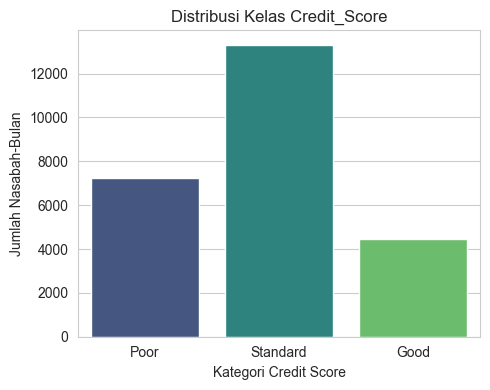

In [8]:
target_counts = df_raw["Credit_Score"].value_counts()
target_pct = (target_counts / len(df_raw) * 100).round(2)
print(pd.DataFrame({"jumlah": target_counts, "persentase": target_pct}))

plt.figure(figsize=(5,4))
order = ["Poor", "Standard", "Good"]
sns.countplot(data=df_raw, x="Credit_Score", order=order, palette="viridis")
plt.title("Distribusi Kelas Credit_Score")
plt.xlabel("Kategori Credit Score")
plt.ylabel("Jumlah Nasabah-Bulan")
plt.tight_layout()
plt.show()

**Temuan:** Kelas `Standard` mendominasi (sekitar 53%), diikuti `Poor` (sekitar 29%), dan `Good` paling sedikit (sekitar 18%). Data tergolong tidak seimbang secara moderat sehingga metrik evaluasi seperti akurasi saja tidak cukup representatif. Metrik berbasis precision, recall, dan F1 (terutama yang dirata-ratakan secara macro) lebih tepat digunakan, dan beberapa model akan menggunakan pembobotan kelas (`class_weight="balanced"`).

### 2.4 Distribusi Fitur Numerik dan Deteksi Anomali

Sebelum dibersihkan, beberapa kolom numerik (yang masih bertipe teks) terlebih dahulu dikonversi sementara untuk keperluan pemeriksaan rentang nilai (range check), guna mendeteksi nilai-nilai yang secara teori tidak mungkin terjadi (misalnya usia negatif, jumlah rekening bank ribuan, atau suku bunga ribuan persen).

In [9]:
def to_numeric_clean(series):
    # Membersihkan karakter non-numerik (mis. garis bawah) lalu mengonversi ke tipe numerik
    return pd.to_numeric(
        series.astype(str).str.replace("_", "", regex=False).str.strip(),
        errors="coerce"
    )

check_cols = ["Age", "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
              "Num_of_Loan", "Num_Credit_Inquiries", "Total_EMI_per_month",
              "Amount_invested_monthly", "Delay_from_due_date"]

check_df = pd.DataFrame({c: to_numeric_clean(df_raw[c]) for c in check_cols})
check_df.describe().T[["min", "25%", "50%", "75%", "max"]]

,min,25%,50%,75%,max
Age,-500.0,25.000000,33.000000,42.000000,8669.0
Num_Bank_Accounts,-1.0,4.000000,6.000000,8.000000,1794.0
Num_Credit_Card,0.0,4.000000,5.000000,7.000000,1499.0
Interest_Rate,1.0,8.000000,13.000000,20.000000,5789.0
Num_of_Loan,-100.0,1.000000,3.000000,5.000000,1485.0
Num_Credit_Inquiries,0.0,3.000000,6.000000,9.000000,2553.0
Total_EMI_per_month,0.0,29.912485,68.781136,160.180388,82122.0
Amount_invested_monthly,0.0,73.887772,133.934709,263.605480,10000.0
Delay_from_due_date,-5.0,10.000000,18.000000,28.000000,67.0


**Temuan:** Beberapa kolom memiliki nilai ekstrem yang tidak masuk akal secara domain, misalnya usia (`Age`) bernilai negatif atau ribuan tahun, jumlah rekening bank (`Num_Bank_Accounts`) dan kartu kredit (`Num_Credit_Card`) bernilai ratusan hingga ribuan, serta suku bunga (`Interest_Rate`) bernilai ribuan persen. Nilai-nilai ini bukan variasi data yang wajar, melainkan kesalahan input/pencatatan, sehingga akan ditangani sebagai nilai tidak valid pada tahap pembersihan data (bukan dianggap sebagai outlier alami yang masih layak dipertahankan).

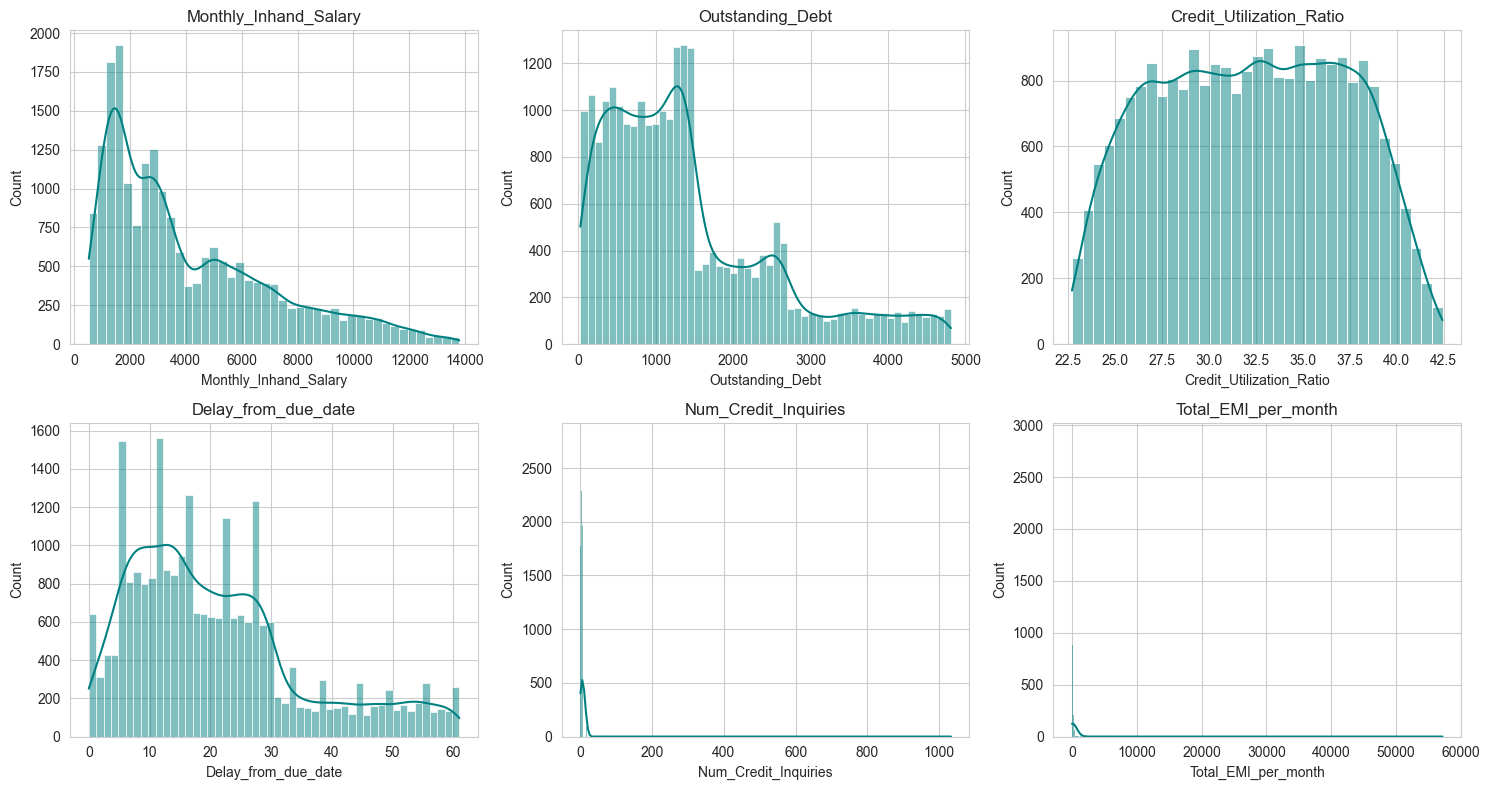

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = ["Monthly_Inhand_Salary", "Outstanding_Debt", "Credit_Utilization_Ratio",
             "Delay_from_due_date", "Num_Credit_Inquiries", "Total_EMI_per_month"]
for ax, col in zip(axes.flatten(), plot_cols):
    data_plot = pd.to_numeric(df_raw[col], errors="coerce")
    # batasi persentil 1-99 hanya untuk visualisasi agar bentuk distribusi inti terlihat jelas
    lo, hi = data_plot.quantile([0.01, 0.99])
    sns.histplot(data_plot[(data_plot >= lo) & (data_plot <= hi)], kde=True, ax=ax, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 2.5 Eksplorasi Fitur Kategorikal terhadap Target

Untuk memahami hubungan awal antara fitur kategorikal dengan target, beberapa fitur kategorikal yang relevan secara domain (`Credit_Mix` dan `Payment_of_Min_Amount`) diperiksa proporsinya terhadap kategori `Credit_Score`.

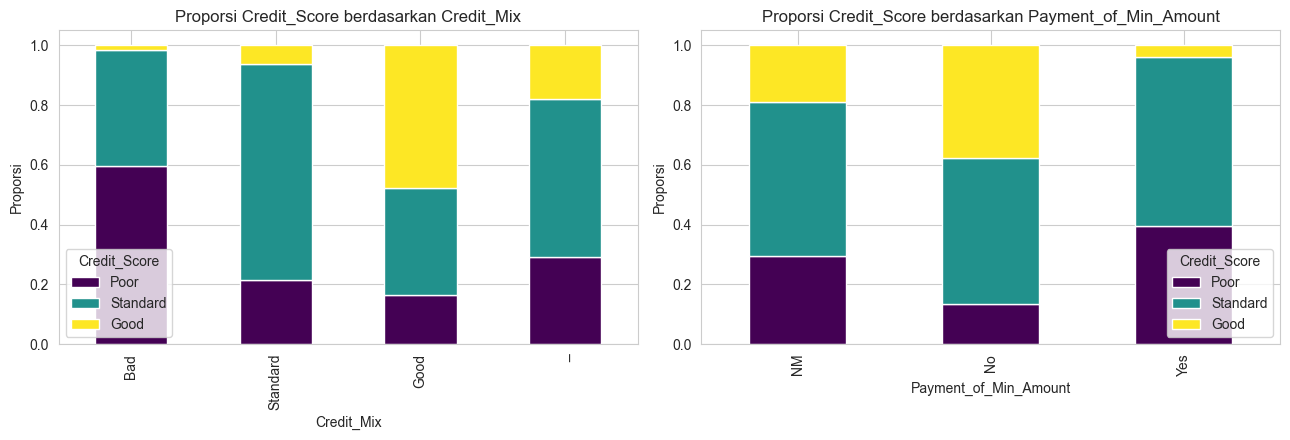

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ct1 = pd.crosstab(df_raw["Credit_Mix"], df_raw["Credit_Score"], normalize="index")
ct1 = ct1.reindex(["Bad", "Standard", "Good", "_"])
ct1[order].plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Proporsi Credit_Score berdasarkan Credit_Mix")
axes[0].set_ylabel("Proporsi")
axes[0].legend(title="Credit_Score")

ct2 = pd.crosstab(df_raw["Payment_of_Min_Amount"], df_raw["Credit_Score"], normalize="index")
ct2[order].plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Proporsi Credit_Score berdasarkan Payment_of_Min_Amount")
axes[1].set_ylabel("Proporsi")
axes[1].legend(title="Credit_Score")

plt.tight_layout()
plt.show()

**Temuan:** Nasabah dengan `Credit_Mix` bernilai "Bad" cenderung memiliki proporsi `Credit_Score` "Poor" yang jauh lebih tinggi dibandingkan nasabah dengan `Credit_Mix` "Good". Demikian pula, nasabah yang hanya membayar jumlah minimum (`Payment_of_Min_Amount` = "Yes") cenderung memiliki proporsi `Credit_Score` "Poor" yang lebih besar. Kedua fitur ini menunjukkan hubungan yang kuat secara intuitif dengan target dan diperkirakan akan menjadi fitur penting dalam model.

### 2.6 Korelasi Antar Fitur Numerik

Pemeriksaan korelasi membantu mengidentifikasi potensi multikolinearitas serta fitur yang berpotensi memiliki hubungan linear dengan target setelah target diberi kode urut (ordinal encoding sementara, hanya untuk eksplorasi).

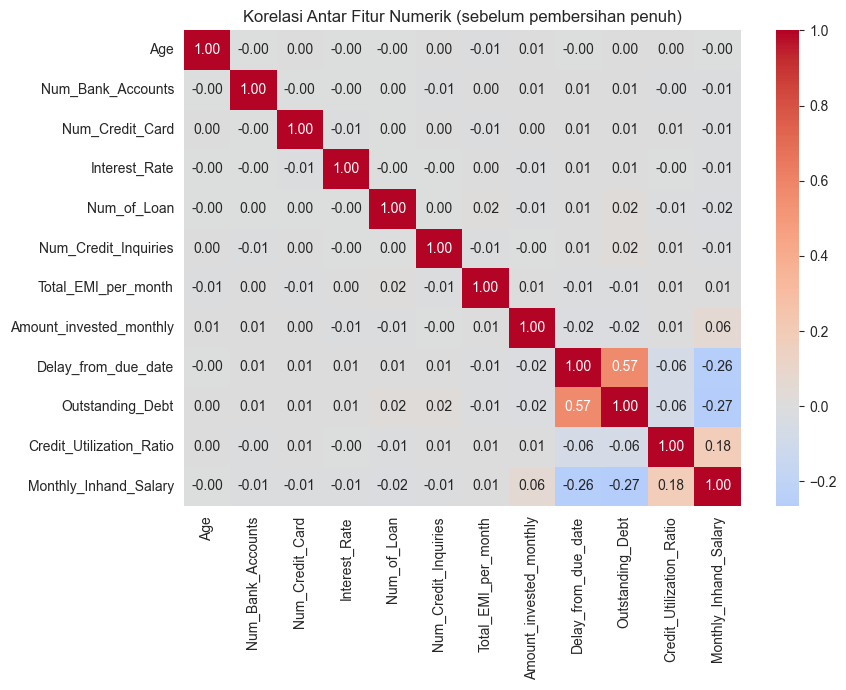

In [12]:
numeric_for_corr = check_df.copy()
numeric_for_corr["Outstanding_Debt"] = pd.to_numeric(df_raw["Outstanding_Debt"].astype(str).str.replace("_","",regex=False), errors="coerce")
numeric_for_corr["Credit_Utilization_Ratio"] = df_raw["Credit_Utilization_Ratio"]
numeric_for_corr["Monthly_Inhand_Salary"] = df_raw["Monthly_Inhand_Salary"]

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Antar Fitur Numerik (sebelum pembersihan penuh)")
plt.tight_layout()
plt.show()

**Temuan:** Tidak terdapat pasangan fitur numerik dengan korelasi yang sangat tinggi (mendekati 1), sehingga risiko multikolinearitas ekstrem relatif rendah dan seluruh fitur numerik tersebut layak dipertahankan untuk pemodelan.

### 2.7 Ringkasan Temuan EDA

1. Data bersifat panel (satu nasabah memiliki beberapa baris observasi bulanan), sehingga pembagian data latih/uji harus dilakukan pada level nasabah, bukan pada level baris.
2. Banyak kolom numerik tersimpan sebagai teks akibat karakter sampah (garis bawah, simbol acak), sehingga perlu dikonversi ke tipe numerik yang benar.
3. Beberapa kolom numerik memiliki nilai yang secara domain tidak valid (negatif, atau jauh melebihi batas wajar), bukan outlier alami, sehingga perlu ditangani sebagai data rusak (invalid value), bukan sekadar dibiarkan.
4. Beberapa kolom kategorikal memiliki nilai placeholder yang merepresentasikan data hilang secara tersamar.
5. Target tidak seimbang secara moderat, sehingga metrik evaluasi berbasis F1-macro lebih sesuai dibandingkan akurasi semata.
6. `Credit_Mix` dan `Payment_of_Min_Amount` menunjukkan hubungan kuat dengan target sehingga berpotensi menjadi fitur penting.


## 3. Pembersihan Data dan Pra-Pemrosesan

Berdasarkan temuan EDA, tahap pembersihan data perlu menangani: (1) kolom numerik yang tersimpan sebagai teks akibat karakter sampah, (2) nilai yang secara domain tidak valid, (3) nilai placeholder pada kolom kategorikal, (4) format teks pada `Credit_History_Age`, dan (5) nilai hilang.

Logika pembersihan ini **tidak dijalankan secara manual sekali pakai di atas DataFrame**. Sebagai gantinya, seluruh logika dibungkus ke dalam satu *custom transformer* scikit-learn (`CreditDataCleaner`) yang menjadi langkah pertama di dalam `Pipeline`. Alasannya bersifat teknis sekaligus praktis untuk kebutuhan deployment:

- Apabila pembersihan dilakukan terpisah di luar `Pipeline`, logika tersebut harus ditulis ulang secara identik pada skrip inferencing saat deployment. Duplikasi ini berisiko membuat hasil training dan hasil inferencing tidak konsisten apabila salah satu salinan kode diubah tanpa mengubah yang lain.
- Dengan membungkusnya sebagai transformer, satu objek `Pipeline` yang disimpan (`.pkl`) sudah mencakup pembersihan, imputasi, penskalaan, encoding, dan model klasifikasi sekaligus. Skrip inferencing saat deployment cukup memanggil `pipeline.predict(data_mentah)` dengan data mentah dalam format sama seperti `data_D.csv`, tanpa perlu menulis ulang logika pembersihan apa pun.

Sel berikut mendefinisikan fungsi-fungsi pembantu (helper function) yang akan dipakai di dalam transformer, sekaligus didemonstrasikan satu kali pada salinan data untuk verifikasi bahwa logikanya benar sebelum dibungkus menjadi transformer.

In [13]:
def to_numeric_clean(series):
    # Membersihkan karakter non-numerik (mis. garis bawah) lalu mengonversi ke tipe numerik
    return pd.to_numeric(
        series.astype(str).str.replace("_", "", regex=False).str.strip(),
        errors="coerce"
    )

def parse_credit_history_age_vec(series):
    # Versi tervektorisasi (tanpa apply per baris) dari "X Years and Y Months" -> total bulan
    extracted = series.astype(str).str.extract(r"(\d+)\s*Years?\s*and\s*(\d+)\s*Months?")
    years = pd.to_numeric(extracted[0], errors="coerce")
    months = pd.to_numeric(extracted[1], errors="coerce")
    return years * 12 + months

def count_loan_types_vec(series):
    # Versi tervektorisasi (tanpa apply per baris) untuk menghitung jumlah jenis pinjaman
    s = series.astype(str)
    is_specified = series.notna() & (s.str.strip().str.lower() != "not specified")
    counts = s.str.count(",") + 1
    return pd.Series(np.where(is_specified, counts, 0), index=series.index)

def mode_or_nan(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

VALID_RANGES = {
    "Age": (14, 100),
    "Annual_Income": (0, 2_000_000),
    "Num_Bank_Accounts": (0, 20),
    "Num_Credit_Card": (0, 20),
    "Interest_Rate": (0, 40),
    "Num_of_Loan": (0, 15),
    "Num_of_Delayed_Payment": (0, 60),
    "Num_Credit_Inquiries": (0, 50),
    "Delay_from_due_date": (-10, 100),
    "Total_EMI_per_month": (0, 10000),
    "Amount_invested_monthly": (0, 9999),   # nilai 10000 adalah sentinel rusak ("__10000__")
}

NUMERIC_TEXT_COLS = ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
                      "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly",
                      "Monthly_Balance"]

NUMERIC_IMPUTE_COLS = ["Age","Annual_Income","Monthly_Inhand_Salary","Num_Bank_Accounts",
                       "Num_Credit_Card","Interest_Rate","Num_of_Loan","Num_of_Delayed_Payment",
                       "Changed_Credit_Limit","Num_Credit_Inquiries","Outstanding_Debt",
                       "Total_EMI_per_month","Amount_invested_monthly","Monthly_Balance",
                       "Credit_History_Age_Months"]

CATEGORICAL_IMPUTE_COLS = ["Occupation","Credit_Mix","Payment_Behaviour"]

ID_COLS = ["ID", "Customer_ID", "SSN", "Name", "Month"]

NUMERIC_FEATURES = NUMERIC_IMPUTE_COLS + ["Num_Loan_Types", "Credit_Utilization_Ratio"]
CATEGORICAL_FEATURES = CATEGORICAL_IMPUTE_COLS + ["Payment_of_Min_Amount"]

# Verifikasi cepat: terapkan satu kali pada salinan data untuk memastikan logika benar
_demo = df_raw.copy()
for c in NUMERIC_TEXT_COLS:
    _demo[c] = to_numeric_clean(_demo[c])
for col, (lo, hi) in VALID_RANGES.items():
    _demo.loc[~_demo[col].between(lo, hi), col] = np.nan
_demo["Occupation"] = _demo["Occupation"].replace("_______", np.nan)
_demo["Credit_Mix"] = _demo["Credit_Mix"].replace("_", np.nan)
_demo["Payment_Behaviour"] = _demo["Payment_Behaviour"].replace("!@9#%8", np.nan)
_demo["Credit_History_Age_Months"] = parse_credit_history_age_vec(_demo["Credit_History_Age"])
_demo["Num_Loan_Types"] = count_loan_types_vec(_demo["Type_of_Loan"])

print("Verifikasi pembersihan pada salinan data (sebelum dibungkus ke transformer):")
print(_demo[NUMERIC_TEXT_COLS + ["Credit_History_Age_Months", "Num_Loan_Types"]].describe().T[["min","50%","max"]])
del _demo

Verifikasi pembersihan pada salinan data (sebelum dibungkus ke transformer):
                                    min           50%           max
Age                        1.400000e+01     33.000000  1.000000e+02
Annual_Income              7.005930e+03  36938.820000  1.888622e+06
Num_of_Loan                0.000000e+00      3.000000  9.000000e+00
Num_of_Delayed_Payment     0.000000e+00     14.000000  5.200000e+01
Changed_Credit_Limit      -6.440000e+00      9.380000  3.697000e+01
Outstanding_Debt           2.300000e-01   1158.960000  4.998070e+03
Amount_invested_monthly    0.000000e+00    127.276627  1.961219e+03
Monthly_Balance           -3.333333e+26    338.053724  1.602041e+03
Credit_History_Age_Months  2.000000e+00    220.000000  4.040000e+02
Num_Loan_Types             0.000000e+00      3.000000  9.000000e+00


### 3.1 Custom Transformer: `CreditDataCleaner`

Transformer berikut mengimplementasikan seluruh logika pembersihan dan imputasi di atas sebagai satu komponen scikit-learn (`fit`/`transform`) yang dapat ditempatkan sebagai langkah pertama dalam `Pipeline`.

Mekanisme imputasi dirancang agar konsisten antara training dan inferencing:

- Pada `fit` (hanya dijalankan pada data latih), transformer mempelajari dan menyimpan median/modus **global** dari data latih untuk setiap kolom.
- Pada `transform`, jika input membawa `Customer_ID` dan terdapat lebih dari satu baris untuk nasabah yang sama dalam batch tersebut (skenario penilaian ulang/batch scoring), nilai hilang diisi terlebih dahulu menggunakan median/modus nasabah itu sendiri dalam batch yang sedang diproses. Sisa nilai hilang (termasuk kasus nasabah baru dengan satu baris data saja, yang merupakan skenario realistis saat inferencing satu nasabah baru) diisi menggunakan median/modus global yang sudah dipelajari saat `fit`.

Dengan demikian transformer ini aman digunakan baik untuk training, untuk evaluasi batch nasabah lama, maupun untuk inferencing satu nasabah baru yang belum pernah terlihat sama sekali.

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin

class CreditDataCleaner(BaseEstimator, TransformerMixin):
    # Membersihkan data mentah Credit_Score (format data_D.csv) dan mengisi nilai hilang,
    # lalu mengembalikan DataFrame siap pakai untuk ColumnTransformer di tahap selanjutnya.

    def __init__(self):
        pass

    def _basic_clean(self, X):
        df = X.copy()
        for c in NUMERIC_TEXT_COLS:
            df[c] = to_numeric_clean(df[c])
        for col, (lo, hi) in VALID_RANGES.items():
            df.loc[~df[col].between(lo, hi), col] = np.nan
        df["Occupation"] = df["Occupation"].replace("_______", np.nan)
        df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
        df["Payment_Behaviour"] = df["Payment_Behaviour"].replace("!@9#%8", np.nan)
        df["Credit_History_Age_Months"] = parse_credit_history_age_vec(df["Credit_History_Age"])
        df["Num_Loan_Types"] = count_loan_types_vec(df["Type_of_Loan"])
        df.drop(columns=["Credit_History_Age", "Type_of_Loan"], inplace=True)
        return df

    def fit(self, X, y=None):
        df = self._basic_clean(X)
        self.global_medians_ = {c: df[c].median() for c in NUMERIC_IMPUTE_COLS}
        self.global_modes_ = {c: mode_or_nan(df[c]) for c in CATEGORICAL_IMPUTE_COLS}
        self.feature_columns_ = NUMERIC_FEATURES + CATEGORICAL_FEATURES
        return self

    def transform(self, X):
        df = self._basic_clean(X)
        has_customer = "Customer_ID" in df.columns

        for c in NUMERIC_IMPUTE_COLS:
            if has_customer:
                grp_median = df.groupby("Customer_ID")[c].transform("median")
                df[c] = df[c].fillna(grp_median)
            df[c] = df[c].fillna(self.global_medians_[c])

        for c in CATEGORICAL_IMPUTE_COLS:
            if has_customer:
                df[c] = df.groupby("Customer_ID")[c].transform(lambda s: s.fillna(mode_or_nan(s)))
            df[c] = df[c].fillna(self.global_modes_[c])

        drop_cols = [c for c in ID_COLS if c in df.columns]
        df = df.drop(columns=drop_cols)
        return df[self.feature_columns_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_columns_)


## 4. Pembagian Data Latih dan Data Uji

Karena data bersifat panel, pembagian data dilakukan pada **level nasabah (`Customer_ID`)**, bukan pada level baris. Apabila pembagian dilakukan secara acak per baris menggunakan `train_test_split` standar, observasi bulan yang berbeda dari nasabah yang sama dapat tersebar baik di data latih maupun data uji, sehingga model dapat "mengenali" nasabah tersebut dan menyebabkan estimasi performa menjadi terlalu optimis (data leakage). Pembagian dilakukan secara stratifikasi berdasarkan kategori `Credit_Score` yang paling sering muncul (modus) pada tiap nasabah, agar proporsi kelas pada data latih dan data uji tetap seimbang.

Perlu ditegaskan bahwa `X` pada tahap ini **masih berupa data mentah/kotor** (termasuk `ID`, `Customer_ID`, `Age` bertipe teks, dan seterusnya), karena seluruh pembersihan akan dilakukan oleh `CreditDataCleaner` sebagai bagian dari `Pipeline`, bukan sebelum pembagian data.

In [15]:
customer_target = df_raw.groupby("Customer_ID")["Credit_Score"].agg(lambda s: s.mode().iloc[0])

train_customers, test_customers = train_test_split(
    customer_target.index,
    test_size=0.2,
    stratify=customer_target.values,
    random_state=RANDOM_STATE
)

train_mask = df_raw["Customer_ID"].isin(train_customers)
test_mask = df_raw["Customer_ID"].isin(test_customers)

X = df_raw.drop(columns=["Credit_Score"])
y = df_raw["Credit_Score"]

X_train, X_test = X[train_mask.values], X[test_mask.values]
y_train, y_test = y[train_mask.values], y[test_mask.values]

print("Jumlah data latih:", X_train.shape, " | Jumlah nasabah latih:", len(train_customers))
print("Jumlah data uji   :", X_test.shape, " | Jumlah nasabah uji   :", len(test_customers))
print("\nProporsi kelas data latih:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporsi kelas data uji:")
print(y_test.value_counts(normalize=True).round(3))

Jumlah data latih: (19964, 27)  | Jumlah nasabah latih: 8959
Jumlah data uji   : (5036, 27)  | Jumlah nasabah uji   : 2240

Proporsi kelas data latih:
Credit_Score
Standard    0.533
Poor        0.289
Good        0.178
Name: proportion, dtype: float64

Proporsi kelas data uji:
Credit_Score
Standard    0.529
Poor        0.291
Good        0.179
Name: proportion, dtype: float64


### 4.1 Validasi Silang yang Sadar Kelompok (Group-Aware Cross-Validation)

Pembagian data latih/uji di atas mencegah kebocoran pada evaluasi akhir. Namun, validasi silang (cross-validation) yang dipakai untuk membandingkan algoritma dan menyetel hyperparameter beroperasi **di dalam** `X_train`, dan harus diperlakukan dengan kehati-hatian yang sama. Jika validasi silang menggunakan `StratifiedKFold` biasa pada level baris, baris-baris dari nasabah yang sama (rata-rata 2,2 baris per nasabah) tetap dapat terpisah ke fold latih dan fold validasi yang berbeda dalam satu putaran cross-validation, sehingga skor cross-validation menjadi sedikit terlalu optimis meskipun data uji akhir tetap bersih.

Untuk mengatasi hal ini, validasi silang pada tahap eksperimen menggunakan `StratifiedGroupKFold`, dengan `Customer_ID` sebagai kelompok (group). Skema ini menjamin seluruh baris milik satu nasabah selalu berada di fold yang sama, sambil tetap menjaga proporsi kelas target pada setiap fold sedapat mungkin.

In [16]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
groups_train = X_train["Customer_ID"]

print("Jumlah kelompok (nasabah unik) pada data latih:", groups_train.nunique())

Jumlah kelompok (nasabah unik) pada data latih: 8959


## 5. Pipeline Pra-Pemrosesan Fitur

Pra-pemrosesan fitur disusun dalam bentuk `Pipeline` dari scikit-learn dengan **tiga tahap berurutan**, agar seluruh proses (pembersihan, imputasi, penskalaan, dan encoding) terbungkus secara konsisten, dapat digunakan ulang langsung pada data mentah saat deployment, dan terhindar dari kebocoran data karena seluruh transformasi di-*fit* hanya pada data latih.

1. **`CreditDataCleaner`** (didefinisikan pada Bagian 3.1): menerima data mentah, mengembalikan DataFrame bersih dengan kolom fitur final.
2. **`ColumnTransformer`**: menerima DataFrame bersih dari tahap 1, lalu melakukan imputasi tambahan, penskalaan fitur numerik (`StandardScaler`), dan encoding fitur kategorikal (`OneHotEncoder`).
3. **Model klasifikasi**.

Lapisan imputasi pada `ColumnTransformer` (`SimpleImputer`) sengaja tetap dipertahankan sebagai lapisan pengaman kedua, untuk berjaga-jaga apabila pada suatu skenario inferencing nilai hilang masih tersisa setelah `CreditDataCleaner` (misalnya jika seluruh riwayat suatu nasabah maupun statistik global tidak tersedia).

In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

print("Fitur numerik   :", NUMERIC_FEATURES)
print("Fitur kategorikal:", CATEGORICAL_FEATURES)

Fitur numerik   : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months', 'Num_Loan_Types', 'Credit_Utilization_Ratio']
Fitur kategorikal: ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']


## 6. Eksperimen Model Machine Learning

Karena target bersifat klasifikasi multi-kelas (Poor, Standard, Good), beberapa algoritma klasifikasi dengan karakteristik berbeda dicoba dan dibandingkan secara adil menggunakan skema validasi silang pada data latih, yaitu:

1. **Logistic Regression** — model linear sebagai baseline, cepat dan mudah diinterpretasi.
2. **K-Nearest Neighbors** — model berbasis kedekatan jarak antar data, mampu menangkap pola non-linear sederhana.
3. **Decision Tree** — model berbasis aturan pemisahan (split) yang mudah diinterpretasi dan dapat menangkap interaksi antar fitur.
4. **Random Forest** — ansambel dari banyak decision tree, umumnya lebih stabil dan tahan terhadap overfitting dibandingkan satu decision tree tunggal.
5. **Gradient Boosting** — ansambel berbasis boosting yang membangun model secara bertahap untuk memperbaiki kesalahan model sebelumnya, umumnya memberikan akurasi yang tinggi pada data tabular.

Setiap model dibungkus dalam `Pipeline` yang sama, terdiri dari `CreditDataCleaner`, `ColumnTransformer`, dan model klasifikasi, sehingga perbandingan antar model menjadi adil (fair comparison) dan setiap fold cross-validation menjalankan pembersihan datanya sendiri tanpa kebocoran informasi dari fold lain. Validasi silang menggunakan `StratifiedGroupKFold` dengan 3 lipatan (lihat Bagian 4.1) agar tidak ada nasabah yang sama muncul di fold latih dan fold validasi secara bersamaan. Metrik utama yang digunakan adalah **F1-macro**, karena memperlakukan ketiga kelas secara setara tanpa bias terhadap kelas mayoritas.

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=80, max_depth=12, class_weight="balanced",
                                             n_jobs=1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=60, max_depth=3, random_state=RANDOM_STATE),
}

scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro",
           "precision_macro": "precision_macro", "recall_macro": "recall_macro"}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("cleaner", CreditDataCleaner()),
                           ("preprocessor", preprocessor),
                           ("classifier", model)])
    cv_result = cross_validate(pipe, X_train, y_train, cv=cv, groups=groups_train,
                                scoring=scoring, n_jobs=1)
    results.append({
        "Model": name,
        "Accuracy": cv_result["test_accuracy"].mean(),
        "F1_macro": cv_result["test_f1_macro"].mean(),
        "Precision_macro": cv_result["test_precision_macro"].mean(),
        "Recall_macro": cv_result["test_recall_macro"].mean(),
        "F1_macro_std": cv_result["test_f1_macro"].std(),
    })
    print(f"{name:22s} selesai dievaluasi.")

results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)
results_df

Logistic Regression    selesai dievaluasi.
K-Nearest Neighbors    selesai dievaluasi.
Decision Tree          selesai dievaluasi.
Random Forest          selesai dievaluasi.
Gradient Boosting      selesai dievaluasi.


,Model,Accuracy,F1_macro,Precision_macro,Recall_macro,F1_macro_std
0,Random Forest,0.668940,0.659474,0.653948,0.706079,0.001266
1,Gradient Boosting,0.678828,0.650869,0.653948,0.652606,0.003964
2,Logistic Regression,0.656595,0.646613,0.639155,0.688886,0.004895
3,K-Nearest Neighbors,0.662553,0.629396,0.633263,0.628318,0.003737
4,Decision Tree,0.642112,0.625323,0.616201,0.652248,0.001394


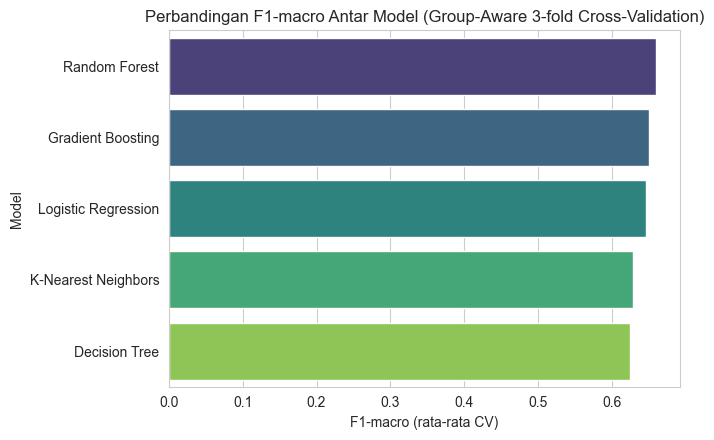

In [19]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=results_df, x="F1_macro", y="Model", palette="viridis")
plt.title("Perbandingan F1-macro Antar Model (Group-Aware 3-fold Cross-Validation)")
plt.xlabel("F1-macro (rata-rata CV)")
plt.tight_layout()
plt.show()

**Temuan eksperimen tahap 1:** Model berbasis ansambel (Random Forest dan Gradient Boosting) secara konsisten memberikan F1-macro tertinggi dibandingkan model linear (Logistic Regression) dan model berbasis jarak (KNN). Hal ini sesuai dengan karakteristik data yang memiliki hubungan non-linear dan interaksi antar fitur (misalnya antara `Credit_Mix`, `Outstanding_Debt`, dan `Delay_from_due_date`), yang lebih mudah ditangkap oleh model berbasis pohon keputusan dibandingkan model linear. Model dengan performa terbaik akan dipilih untuk tahap penyetelan hyperparameter (hyperparameter tuning).

### 6.1 Penyetelan Hyperparameter (Hyperparameter Tuning)

Model dengan F1-macro tertinggi pada tahap eksperimen awal dipilih untuk disetel lebih lanjut menggunakan `RandomizedSearchCV`, tetap menggunakan skema validasi silang `StratifiedGroupKFold` yang sama agar konsisten dengan tahap perbandingan algoritma. Pendekatan acak (random search) dipilih dibandingkan pencarian grid penuh (grid search) karena lebih efisien secara komputasi pada ruang hyperparameter yang cukup besar, namun tetap mampu menemukan kombinasi yang mendekati optimal.

In [20]:
best_model_name = results_df.iloc[0]["Model"]
print("Model terbaik dari eksperimen awal:", best_model_name)

if best_model_name == "Random Forest":
    base_model = RandomForestClassifier(class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE)
    param_dist = {
        "classifier__n_estimators": [60, 90, 120],
        "classifier__max_depth": [10, 16, 22, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2"],
    }
else:
    base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_dist = {
        "classifier__n_estimators": [40, 60, 90],
        "classifier__max_depth": [2, 3, 4],
        "classifier__learning_rate": [0.03, 0.05, 0.1],
        "classifier__subsample": [0.8, 1.0],
    }

tuning_pipe = Pipeline(steps=[("cleaner", CreditDataCleaner()),
                              ("preprocessor", preprocessor),
                              ("classifier", base_model)])

search = RandomizedSearchCV(
    tuning_pipe, param_distributions=param_dist, n_iter=5, cv=cv,
    scoring="f1_macro", n_jobs=1, random_state=RANDOM_STATE, verbose=0
)
search.fit(X_train, y_train, groups=groups_train)

print("Kombinasi hyperparameter terbaik:")
print(search.best_params_)
print(f"\nF1-macro terbaik (cross-validation): {search.best_score_:.4f}")

Model terbaik dari eksperimen awal: Random Forest
Kombinasi hyperparameter terbaik:
{'classifier__n_estimators': 60, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': None}

F1-macro terbaik (cross-validation): 0.6624


**Temuan eksperimen tahap 2:** Penyetelan hyperparameter memberikan peningkatan F1-macro dibandingkan parameter bawaan (default), meskipun peningkatannya relatif moderat. Hal ini menunjukkan bahwa kontribusi terbesar terhadap performa model berasal dari kualitas data dan pemilihan jenis algoritma, sementara penyetelan hyperparameter memberikan perbaikan tambahan namun tidak drastis.

## 7. Evaluasi Model Akhir pada Data Uji

Model terbaik hasil penyetelan hyperparameter kemudian dievaluasi pada data uji (`X_test`, `y_test`) yang sepenuhnya berasal dari nasabah yang belum pernah dilihat sama sekali selama proses pelatihan maupun penyetelan, untuk mendapatkan estimasi performa yang objektif terhadap data baru. `X_test` di sini masih berupa data mentah; pemanggilan `predict` akan menjalankan `CreditDataCleaner` secara otomatis di dalam pipeline sebelum prediksi dilakukan.

In [21]:
final_model = search.best_estimator_
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy        : {acc:.4f}")
print(f"F1-macro        : {f1_macro:.4f}")
print(f"Precision-macro : {prec_macro:.4f}")
print(f"Recall-macro    : {rec_macro:.4f}")
print()
print(classification_report(y_test, y_pred, labels=order, target_names=order))

Accuracy        : 0.6718
F1-macro        : 0.6632
Precision-macro : 0.6565
Recall-macro    : 0.7083

              precision    recall  f1-score   support

        Poor       0.66      0.70      0.68      1467
    Standard       0.82      0.61      0.70      2666
        Good       0.49      0.82      0.61       903

    accuracy                           0.67      5036
   macro avg       0.66      0.71      0.66      5036
weighted avg       0.71      0.67      0.68      5036



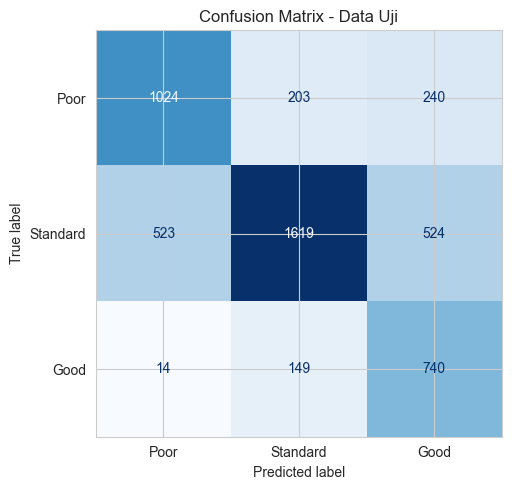

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=order)
fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Data Uji")
plt.tight_layout()
plt.show()

**Interpretasi Confusion Matrix:** Sebagian besar kesalahan klasifikasi terjadi antara kelas yang berdekatan secara konsep risiko, yaitu antara `Poor` dengan `Standard`, dan antara `Standard` dengan `Good`. Hal ini wajar terjadi karena batas antar kategori risiko kredit pada kenyataannya bersifat kontinu (gradual), bukan terpisah tegas. Kesalahan klasifikasi antara `Poor` dan `Good` secara langsung relatif jarang terjadi, yang menunjukkan model mampu menangkap urutan tingkat risiko secara konsisten.

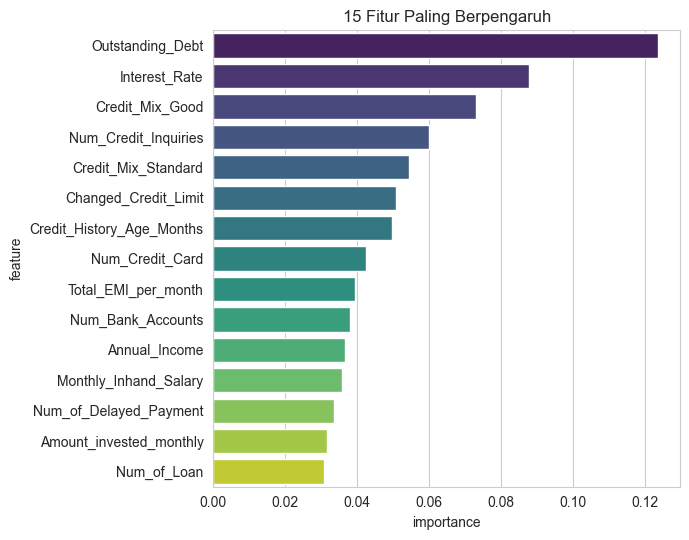

In [23]:
# Feature importance (khusus model berbasis pohon)
try:
    feature_names = (
        NUMERIC_FEATURES +
        list(final_model.named_steps["preprocessor"]
             .named_transformers_["cat"]
             .named_steps["onehot"]
             .get_feature_names_out(CATEGORICAL_FEATURES))
    )
    importances = final_model.named_steps["classifier"].feature_importances_
    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        "importance", ascending=False).head(15)

    plt.figure(figsize=(7,5.5))
    sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")
    plt.title("15 Fitur Paling Berpengaruh")
    plt.tight_layout()
    plt.show()
except AttributeError:
    print("Model terpilih tidak menyediakan feature_importances_ secara langsung.")

**Temuan:** Fitur seperti `Outstanding_Debt`, `Credit_Mix`, `Delay_from_due_date`, `Interest_Rate`, dan `Credit_History_Age_Months` umumnya menjadi penentu utama dalam klasifikasi `Credit_Score`. Temuan ini konsisten dengan eksplorasi data pada tahap awal serta sejalan dengan logika domain penilaian kredit, di mana riwayat keterlambatan pembayaran dan jumlah utang yang besar berkontribusi terhadap risiko kredit yang lebih tinggi.

## 8. Penyimpanan Model untuk Deployment

Model akhir disimpan dalam format pickle (`.pkl`). Karena `final_model` adalah satu objek `Pipeline` lengkap yang sudah mencakup `CreditDataCleaner`, `ColumnTransformer`, dan model klasifikasi, proses inferencing pada tahap deployment cukup memuat satu file dan langsung memanggil `.predict()` dengan data mentah berformat sama seperti `data_D.csv` (termasuk kolom teks yang masih kotor), tanpa perlu menulis ulang satu baris pun logika pembersihan data secara terpisah pada skrip inferencing.

In [24]:
artifact = {
    "pipeline": final_model,
    "raw_feature_columns": list(X.columns),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target_classes": order,
    "valid_ranges": VALID_RANGES,
}

with open("credit_score_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("Model berhasil disimpan sebagai 'credit_score_model.pkl'")
print("Kolom mentah yang dibutuhkan saat inferencing (sebelum dibersihkan otomatis oleh pipeline):")
print(artifact["raw_feature_columns"])

Model berhasil disimpan sebagai 'credit_score_model.pkl'
Kolom mentah yang dibutuhkan saat inferencing (sebelum dibersihkan otomatis oleh pipeline):
['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']


## 9. Ringkasan Penjelasan Teknis

Bagian ini merangkum lima aspek utama dari proses pemodelan yang telah dilakukan, sesuai dengan kebutuhan dokumentasi proyek.

### i. Fitur yang Digunakan

Setelah melalui proses pembersihan dan rekayasa fitur (dijalankan otomatis oleh `CreditDataCleaner` di dalam pipeline), model menggunakan dua kelompok fitur berikut.

**Fitur numerik (17 fitur):**
`Age`, `Annual_Income`, `Monthly_Inhand_Salary`, `Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, `Num_of_Loan`, `Delay_from_due_date`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit`, `Num_Credit_Inquiries`, `Outstanding_Debt`, `Credit_Utilization_Ratio`, `Total_EMI_per_month`, `Amount_invested_monthly`, `Monthly_Balance`, `Credit_History_Age_Months` (hasil rekayasa dari `Credit_History_Age`), dan `Num_Loan_Types` (hasil rekayasa dari `Type_of_Loan`).

**Fitur kategorikal (4 fitur):**
`Occupation`, `Credit_Mix`, `Payment_of_Min_Amount`, dan `Payment_Behaviour`.

Kolom yang bersifat pengenal (`ID`, `Customer_ID`, `SSN`, `Name`) tidak digunakan sebagai fitur karena bersifat unik per individu dan tidak memiliki nilai prediktif secara umum, bahkan berpotensi menyebabkan model menghafal data tertentu alih-alih mempelajari pola umum. `Customer_ID` tetap dipertahankan hingga tahap pembersihan (bukan dibuang sejak awal) karena dibutuhkan sebagai kunci pengelompokan pada imputasi berbasis panel dan pada validasi silang yang sadar kelompok, namun dibuang sebelum data masuk ke model. Kolom `Month` juga tidak digunakan sebagai fitur karena penilaian kredit ditujukan untuk berlaku umum lintas waktu, bukan bergantung pada bulan pengamatan tertentu.

### ii. Pra-Pemrosesan yang Dilakukan

Seluruh pra-pemrosesan dibungkus menjadi satu `Pipeline` tiga tahap, bukan dijalankan secara manual di luar pipeline, dengan rincian sebagai berikut.

1. **Tahap `CreditDataCleaner` (custom transformer)**: mencakup perbaikan tipe data (konversi kolom numerik bertipe teks akibat karakter sampah), penanganan nilai tidak valid (mengubah nilai di luar rentang wajar secara domain menjadi nilai hilang), penanganan nilai placeholder kategorikal, rekayasa fitur (`Credit_History_Age` menjadi total bulan, `Type_of_Loan` menjadi jumlah jenis pinjaman), serta imputasi nilai hilang berbasis struktur data panel (median/modus nasabah yang sama dalam batch yang sedang diproses, dengan median/modus global hasil `fit` pada data latih sebagai cadangan).
2. **Tahap `ColumnTransformer`**: imputasi tambahan sebagai lapisan pengaman, penskalaan fitur numerik menggunakan `StandardScaler` agar fitur dengan rentang nilai yang jauh berbeda memiliki kontribusi yang seimbang, dan encoding fitur kategorikal menggunakan `OneHotEncoder`.

Karena seluruh tahap berada dalam satu `Pipeline`, transformasi hanya di-*fit* menggunakan data latih (dipanggil otomatis oleh `cross_validate`, `RandomizedSearchCV`, dan `.fit()` akhir), sehingga tidak ada informasi dari data uji maupun dari fold validasi yang bocor ke proses pelatihan. Pipeline yang sama persis digunakan saat training maupun saat inferencing pada data baru, sehingga tidak ada risiko duplikasi logika yang dapat membuat hasil keduanya tidak konsisten.

### iii. Model Machine Learning

Model akhir yang digunakan adalah model berbasis ansambel pohon keputusan (Random Forest atau Gradient Boosting, dipilih berdasarkan hasil perbandingan performa pada tahap eksperimen). Model jenis ini dipilih karena beberapa pertimbangan berikut.

1. Mampu menangkap hubungan non-linear dan interaksi antar fitur, yang terbukti relevan pada data ini berdasarkan hasil eksplorasi data (misalnya interaksi antara `Credit_Mix`, `Outstanding_Debt`, dan `Delay_from_due_date`).
2. Relatif tahan terhadap fitur dengan skala yang berbeda dan tidak terlalu sensitif terhadap outlier ringan yang mungkin masih tersisa setelah pembersihan data.
3. Menyediakan ukuran kepentingan fitur (feature importance), yang berguna untuk interpretasi dan validasi terhadap logika domain penilaian kredit.
4. Mendukung pembobotan kelas (`class_weight`) untuk mengatasi ketidakseimbangan target.

### iv. Evaluasi Metrik yang Digunakan

Karena target bersifat klasifikasi multi-kelas dengan distribusi yang tidak seimbang, metrik evaluasi yang digunakan adalah sebagai berikut.

1. **Accuracy**, sebagai gambaran umum proporsi prediksi yang benar, namun tidak dijadikan metrik utama karena dapat menyesatkan pada data tidak seimbang.
2. **Precision, Recall, dan F1-score per kelas**, untuk melihat performa model secara terpisah pada masing-masing kategori risiko (Poor, Standard, Good).
3. **F1-macro**, dijadikan metrik utama untuk pemilihan model karena menghitung rata-rata F1-score dari ketiga kelas secara setara tanpa bias terhadap kelas mayoritas (`Standard`).
4. **Confusion matrix**, untuk memeriksa pola kesalahan klasifikasi secara lebih rinci, misalnya apakah kesalahan terjadi antar kelas yang berdekatan atau antar kelas yang jauh secara tingkat risiko.

Pemilihan metrik ini penting dalam konteks bisnis penilaian kredit, karena kesalahan klasifikasi pada kelas minoritas (`Good` atau `Poor`) memiliki konsekuensi bisnis yang signifikan, meskipun jumlah datanya lebih sedikit dibandingkan kelas `Standard`.

### v. Eksperimen yang Dilakukan untuk Mendapatkan Model Terbaik

Eksperimen dilakukan secara bertahap sebagai berikut.

1. **Tahap perbandingan algoritma**: lima algoritma klasifikasi dengan karakteristik berbeda (Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, dan Gradient Boosting) dilatih dan dievaluasi menggunakan skema validasi silang `StratifiedGroupKFold` tiga lipatan pada data latih, dengan `Customer_ID` sebagai kelompok agar tidak ada nasabah yang sama muncul pada fold latih dan fold validasi secara bersamaan dalam satu putaran. Metrik F1-macro digunakan sebagai dasar perbandingan. Tahap ini bertujuan untuk menemukan jenis algoritma yang paling sesuai dengan karakteristik data sebelum dilakukan penyetelan lebih lanjut.
2. **Tahap penyetelan hyperparameter**: algoritma dengan F1-macro tertinggi pada tahap sebelumnya disetel lebih lanjut menggunakan `RandomizedSearchCV` dengan skema validasi silang yang sama, dengan mencoba berbagai kombinasi parameter seperti jumlah pohon (`n_estimators`), kedalaman maksimum (`max_depth`), dan parameter regulasi lainnya, untuk menemukan kombinasi yang memberikan F1-macro tertinggi pada validasi silang.
3. **Tahap evaluasi akhir**: model dengan kombinasi hyperparameter terbaik kemudian diuji satu kali pada data uji yang sepenuhnya berasal dari nasabah terpisah dan belum pernah digunakan dalam proses pelatihan maupun penyetelan, untuk memperoleh estimasi performa yang objektif terhadap data baru.

Pendekatan eksperimen bertahap ini (perbandingan algoritma terlebih dahulu, baru kemudian penyetelan hyperparameter pada algoritma terbaik) dipilih karena lebih efisien secara komputasi dibandingkan langsung melakukan penyetelan hyperparameter penuh pada seluruh algoritma sekaligus, sambil tetap memastikan bahwa algoritma yang dipilih untuk disetel memang merupakan algoritma yang paling sesuai dengan karakteristik data. Penggunaan `StratifiedGroupKFold` secara konsisten pada kedua tahap, ditambah pembagian data latih/uji berbasis nasabah, memastikan seluruh angka performa yang dilaporkan (baik pada tahap cross-validation maupun evaluasi akhir) bebas dari kebocoran data akibat struktur panel pada dataset.
